### Imports:

In [500]:
import requests
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy
import random
from scipy.stats import norm
from scipy import stats


### Visual Crossing API and Dataframe Creation:

In [501]:
# Break down and build up string 
# Api info based off of previous work: Youtube Link: https://youtu.be/RPEsS2hzl-Q Time: 1:28-1:53
url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline/Washington,DC/"
start_date = "-06-01"
separator = "/"
end_date = "-06-30" 
final_append = "?key="
visual_crossing_API_KEY = "GW4267MR27NGP7JH2XVMMMFGP"
include = "&include=days"
include_elements = "&elements=datetime,address,feelslike,humidity,tempmax,tempmin,temp,precip,windspeed,conditions"
month_list = [requests.get(url + str(x) + start_date + separator + str(x) + end_date + final_append + visual_crossing_API_KEY + include + include_elements) for x in range(2025, 2022, -1)]
data_list = [data.json() for data in month_list]

three_year_dfs = [pd.DataFrame(data['days']) for data in data_list]

# Capitalize Columns and change rows to start at 1 instead of 0 
for x in range(len(three_year_dfs)):
    # Index starts at 1
    three_year_dfs[x].index += 1
    # Capitalize Columns
    three_year_dfs[x].columns = three_year_dfs[x].columns.str.title()

# Display Dataframes for all 3 years 
print("June 2025")
display(three_year_dfs[0])
print("June 2024")
display(three_year_dfs[1])
print("June 2023")
display(three_year_dfs[2])


# Now we have the mean and SD so we can calulate the Z-Score by loading in the past 7 days to see if they fit the mean
seven_day_forecast = requests.get(url + "2026-06-08" + separator + "2026-06-14" + final_append + visual_crossing_API_KEY + include + include_elements)
seven_day_forecast = seven_day_forecast.json()
seven_day_forecast =pd.DataFrame(seven_day_forecast['days'])

# Index starts at 1
seven_day_forecast.index += 1

# Capitalize Columns
seven_day_forecast.columns = seven_day_forecast.columns.str.title()

# Display 7-Day Weather Data
print("7 Day Weather June 8th - June 14th, 2026")
display(seven_day_forecast)


June 2025


,Datetime,Tempmax,Tempmin,Temp,Feelslike,Humidity,Precip,Windspeed,Conditions
1,2025-06-01,69.2,48.8,60.5,60.3,52.7,0.000,16.9,Partially cloudy
2,2025-06-02,74.1,51.8,64.3,64.3,51.4,0.000,11.4,Partially cloudy
3,2025-06-03,80.0,55.9,67.9,67.9,59.6,0.000,9.1,Partially cloudy
4,2025-06-04,84.0,61.9,72.4,72.8,67.7,0.000,13.6,Partially cloudy
5,2025-06-05,83.0,66.8,74.4,75.1,73.3,0.000,12.6,Partially cloudy
6,2025-06-06,83.1,67.7,74.8,75.5,76.9,0.000,9.1,Partially cloudy
7,2025-06-07,85.9,70.0,76.5,77.0,73.4,0.160,12.3,"Rain, Partially cloudy"
8,2025-06-08,75.6,70.0,72.7,72.7,80.2,0.066,11.3,"Rain, Overcast"
9,2025-06-09,82.9,68.0,74.4,74.9,78.4,0.011,12.5,"Rain, Partially cloudy"
10,2025-06-10,84.8,71.9,77.1,77.0,68.4,0.000,14.7,Partially cloudy


June 2024


,Datetime,Tempmax,Tempmin,Temp,Feelslike,Humidity,Precip,Windspeed,Conditions
1,2024-06-01,80.9,58.7,70.5,70.4,49.1,0.000,14.0,Partially cloudy
2,2024-06-02,81.1,64.5,73.1,73.3,61.7,0.000,18.1,Partially cloudy
3,2024-06-03,84.6,70.0,77.5,78.0,64.0,0.011,9.0,"Rain, Partially cloudy"
4,2024-06-04,88.0,69.6,78.9,79.7,67.5,0.000,19.2,Partially cloudy
5,2024-06-05,82.1,71.8,76.2,76.8,82.2,0.426,14.6,"Rain, Overcast"
6,2024-06-06,85.9,74.9,79.7,81.4,73.2,0.000,17.0,Partially cloudy
7,2024-06-07,86.9,72.7,79.3,78.6,45.1,0.000,22.4,Partially cloudy
8,2024-06-08,83.9,64.8,76.0,75.5,41.7,0.000,16.0,Partially cloudy
9,2024-06-09,83.0,70.7,76.7,76.7,45.5,0.000,20.8,Partially cloudy
10,2024-06-10,82.1,64.7,74.3,74.2,43.2,0.000,18.0,Partially cloudy


June 2023


,Datetime,Tempmax,Tempmin,Temp,Feelslike,Humidity,Precip,Windspeed,Conditions
1,2023-06-01,83.6,58.6,72.1,72.0,62.8,0.000,11.2,Partially cloudy
2,2023-06-02,92.6,63.5,77.6,77.4,58.4,0.000,9.8,Clear
3,2023-06-03,83.7,62.8,75.3,75.6,64.6,0.000,17.5,Partially cloudy
4,2023-06-04,75.6,60.8,66.7,66.7,62.5,0.000,13.3,Partially cloudy
5,2023-06-05,79.8,58.8,69.5,69.5,56.9,0.000,13.2,Partially cloudy
6,2023-06-06,82.8,60.5,72.6,72.3,41.5,0.000,16.1,Partially cloudy
7,2023-06-07,79.7,62.3,72.1,72.1,41.7,0.000,15.7,Partially cloudy
8,2023-06-08,77.7,60.5,68.7,68.7,48.3,0.000,13.7,Partially cloudy
9,2023-06-09,75.6,59.4,68.4,68.4,46.8,0.000,14.9,Partially cloudy
10,2023-06-10,86.9,58.6,73.2,72.5,46.4,0.000,14.4,Partially cloudy


7 Day Weather June 8th - June 14th, 2026


,Datetime,Tempmax,Tempmin,Temp,Feelslike,Humidity,Precip,Windspeed,Conditions
1,2026-06-08,79.7,68.9,73.9,73.9,58.8,0.000,12.2,Partially cloudy
2,2026-06-09,83.1,63.8,72.7,72.7,55.1,0.000,12.3,Partially cloudy
3,2026-06-10,89.1,71.1,77.6,79.2,76.0,0.097,13.5,"Rain, Overcast"
4,2026-06-11,96.9,73.1,83.9,87.5,69.2,0.003,13.1,Partially cloudy
5,2026-06-12,97.9,72.0,81.7,84.7,71.9,0.111,19.7,"Rain, Partially cloudy"
6,2026-06-13,89.9,71.9,81.3,80.9,55.6,0.000,13.4,Partially cloudy
7,2026-06-14,93.6,72.2,82.1,84.1,63.7,0.010,22.1,Partially cloudy


### Functions for Hypothesis Testing:

In [502]:
def display_content(label: str, x_axis: str, points_color="orange") -> tuple[float,...]: # Return tuple of floats for mean used in Hypothesis Testing Function

    mean = 0
    standard_deviation = 0
    square = lambda x: x ** 2

    # Find the mean
    for x in range(len(three_year_dfs)):
        mean += three_year_dfs[x][label].mean()
        if x == len(three_year_dfs) - 1:
            mean = mean / len(three_year_dfs) 
    
    # Find the Standard Deviation 
    for index in range(len(three_year_dfs)):
        for item in three_year_dfs[index][label]:
            standard_deviation += square((item - mean))
    
    standard_deviation = math.sqrt(standard_deviation / (len(three_year_dfs[0]) + len(three_year_dfs[1]) + len(three_year_dfs[2]) - 1)) # n - 1: for sample standard deviation since we are using a sample of the total June months ever
    
    formatted_labels = {
        "Humidity":"Humidity",
        "Temp":"Temperature",
        "Tempmax":"Max Temperature",
        "Tempmin":"Min Temperature",
        "Feelslike":"Feels Like",
        "Precip":"Precipitation",
        "Windspeed":"Windspeed",
    }
    formatted_label = formatted_labels.get(label)
    z_scores = []

    for val in seven_day_forecast[label]:
        z_scores.append((val - mean) / standard_deviation)
    
    seven_day_forecast[f'{label} Z-Score'] = z_scores
    
    # Spaceing Lines: Utilize a 1000 x values to calculate the normal distribution density: 
    # The bell shaped curve   
    x = np.linspace(mean - (4 * standard_deviation), mean + (4 * standard_deviation), 1000)
    
    y = norm.pdf(x, mean, standard_deviation)
    
    # Start of plot 
    plt.figure(figsize=(12, 8))
    plt.plot(x,y, label="Histroical June Distribution")
    
    # Mean Line
    plt.axvline(mean,color="orange", linestyle="-", linewidth=2, label="Mean")
    
    # Mean Temperature Line
    plt.text(mean, min(y) * .9, f"{round(mean,1)}\n Mean {formatted_label}", rotation = 0, ha = 'center')
    
    for z in [-3, -2, -1, 1, 2, 3]:
        pcnt = ""
        if z % 3 == 0:
            pcnt = "99.7%"
        elif z % 2 == 0:
            pcnt = "95%"
        else:
            pcnt = "68%"
        plt.axvline(mean + z * standard_deviation, color='blue', linestyle="--", alpha = .5)
        plt.text(mean + z * standard_deviation, max(y) * .8, f"{z}σ = ({pcnt})", rotation = 90, ha = 'center')
    
    # label_list
    label_list = seven_day_forecast[label]
    
    # Where each point will be located on the curve 
    points = norm.pdf(label_list, mean, standard_deviation)
    
    plt.plot(label_list, points, '-o', color=points_color, label=f'June 8th - 14th {formatted_label}')
    
    plt.xlabel(x_axis)
    plt.ylabel("Probability Density")
    plt.title(f"Week of June 8th - June 14th {formatted_label} vs Historical Samples")
    plt.legend()
    plt.show()
    print(f"{formatted_labels.get(label)} Table for the Week June 8th - 14th")
    display(seven_day_forecast[['Datetime',label,f'{label} Z-Score']])
    return (float(mean), float(standard_deviation))


# Function for hypothesis testing
def hypothesis_test(label:str, mean:float, std:float, alpha:float):

    print(f"""Two-tail Z-Test:\nHypothesis Testing for {label} with Alpha = {alpha}:\n 
    - Null Hypothesis H₀:  M₀ = Avg = The average {label} during the week June 8th - 14th, 2026 is equal to the historical June average.\n
    - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average {label} during the week June 8th - 14th, 2026 is different from the historical June average.\n""")
    
    square_root = lambda x: math.sqrt(x)
    week_data = seven_day_forecast[label]
    week_mean = week_data.mean()
    n = len(week_data)
    
    # Standard error and Z-Statistic Calulation
    stderror = std / square_root(n)
    z_statictic = (week_mean - mean) / stderror

    # Two-tail test 2 * P(Z >= |Z-Statistic|) = 2 * (1 - P(|Z-Statistic|))
    p_value = 2 * (1 - norm.cdf(abs(z_statictic)))

    print(f"Week Mean: {round(week_data.mean(),2)}")
    print(f"Historical Mean: {round(mean,2)}")
    print(f"Z Statistic: {round(z_statictic,4)}")
    print(f"P-Value: {round(p_value,4)}\n")

    if p_value > alpha:
        print("Based off the Z-test, there is no significant difference between the historical June data and our week sample.")
        print("Fail to reject H₀\n")

    else:
        print("Based off the Z-test, there is significant differences between the historical June data and our week sample.")
        print("Reject H₀\n")

def hypothesis_tests_two_tailed_t(label: str, mean: float, alpha:float):

    print(f"""Two-tail T-Test with sigma unknown:\nHypothesis Testing for {label} with Alpha = {alpha}:\n 
    - Null Hypothesis H₀:  M₀ = Avg = The average {label} during the week June 8th - 14th, 2026 is equal to the historical June average.\n
    - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average {label} during the week June 8th - 14th, 2026 is different from the historical June average.\n""")
    
    week_data = seven_day_forecast[label]

    # Sigma is calculated from the 7-day sample June 8th - June 14th
    resp = stats.ttest_1samp(week_data, popmean=mean, alternative="two-sided")
    
    print(f"Week Mean: {round(week_data.mean(), 2)}")
    print(f"Historical Mean: {round(mean, 2)}")
    print(f"T Statistic: {round(resp.statistic, 4)}")
    print(f"P-Value: {round(resp.pvalue, 4)}\n")
    
    if resp.pvalue > alpha:
        print(f"Based off the two-tailed T-test, there is no significant evidence that the week's average {label} differs from the historical June average.")
        print("Fail to reject H₀\n")
    else:
        print(f"Based off the two-tailed T-test, there is significant evidence that the week's average {label} differs from the historical June average.")
        print("Reject H₀\n")

def hypothesis_tests_left_t(label: str, mean: float, alpha:float):

    print(f"""One-tail T-Test with sigma unknown:\nHypothesis Testing for {label} with Alpha = {alpha}:\n 
    - Null Hypothesis H₀:  M₀ >= Avg where the average {label} during the week June 8th - 14th, 2026 is greater than or equal to the historical June average.\n
    - Alternative Hypothesis 𝐻a:  M₀ < Avg where the average {label} during the week June 8th - 14th, 2026 is less than the historical June average.\n""")
    
    week_data = seven_day_forecast[label]

    # Sigma is calculated from the 7-day sample June 8th - June 14th
    resp = stats.ttest_1samp(week_data, popmean=mean, alternative="less")
    
    print(f"Week Mean: {round(week_data.mean(), 2)}")
    print(f"Historical Mean: {round(mean, 2)}")
    print(f"T Statistic: {round(resp.statistic, 4)}")
    print(f"P-Value: {round(resp.pvalue, 4)}\n")
    
    if resp.pvalue > alpha:
        print(f"Based off the left-tailed T-test, there is no significant evidence that the week's average {label} is less than the historical June average.")
        print("Fail to reject H₀\n")
    else:
        print(f"Based off the left-tailed T-test, there is significant evidence that the week's average {label} is less than the historical June average.")
        print("Reject H₀\n")


def hypothesis_tests_two_sample_t(label:str, historical_df, week_df, alpha: float):

    print(f"""Two-sample T-Test with sigma unknown:\nHypothesis Testing for {label} with Alpha = {alpha}:\n 
    - Null Hypothesis H₀:  Sample mean = Historical mean where the average {label} during the week June 8th - 14th, 2026 is equal to the historical June average.\n
    - Alternative Hypothesis 𝐻a: Sample mean ≠ Historical mean where the average {label} during the week June 8th - 14th, 2026 is not equal to the historical June average.\n""")
    
    combined = []

    # Combine dataframes 
    for x in range(1, len(historical_df), 1):
        if x == 1:
            combined = pd.concat([historical_df[0][label], historical_df[x][label]], ignore_index= True)
        else:
            combined = pd.concat([combined, historical_df[x][label]],ignore_index= True)

    week_vector = week_df[label]

    # We cannot assume the variance are the same, in fact we know they are not.
    data = stats.ttest_ind(combined, week_vector, equal_var=False)

    print(f"Week Mean: {round(week_vector.mean(), 2)}")
    print(f"Historical Mean: {round(combined.mean(), 2)}")
    print(f"T Statistic: {round(data.statistic, 4)}")
    print(f"P Value: {round(data.pvalue, 4)}\n")

    if data.pvalue > alpha:
        print(f"Based off the two-tailed t-test, there is no significant evidence that the weeks sample data and the historical June {label} data have different means.")
        print("Fail to reject H0\n")
    else:
        print(f"Based off the two-tailed t-test, there is significant evidence that the weeks sample data and the historical June {label} data have different means.")
        print("Reject H0\n")


### Normal Distribution, Data Output, and Hypothesis Testing:
- This section looks at whether the observed weather during the week of June 8th - June 14th, 2026 differs significantly from the historical June weather data collected from 2023 - 2025.

- Four hypothesis tests are performed for each weather attribute in our Dataframe:

   - 1. Two-tailed Z-Test
      - Note: A two-tailed Z-Test tells us if our test week June 8th - June 14th 2026 is significantly different from our historical averages determined by our specified $\alpha$ level. 
   - 2. Two-tailed T-Test
   - 3. One-tailed T-Test

   - 4. Two-sample T-Test
      - Lastly we will compare our historical data and our 7-day sample using a two-sample T-Test assumming each has a different variance.

- Notes:

   - Null Hypothesis H₀:  M₀ = Avg = The average attribute during the week June 8th - 14th, 2026 is equal to the historical June average.     
   - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average attribute during the week June 8th - 14th, 2026 is different from the historical June average.
   - We have used the 2 functons to calculate a 3-year historical distribution by calulating the mean, ($\mu$) and standard deviation ($\sigma$) utilizing all days in June 2023 - June 2025 inclusive.
   - The Z-Score indicates how many standard deviations the daily attribute is away from the three-year historical mean.
   - We set $\alpha$ level to $\alpha$ = 0.05. This can be changed if needed.

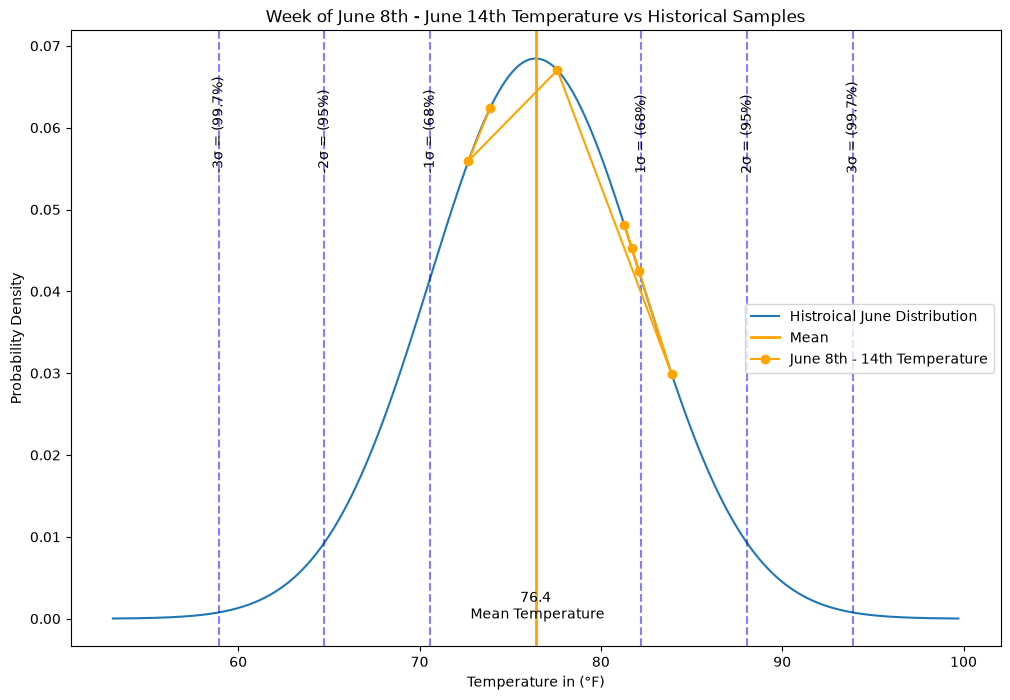

Temperature Table for the Week June 8th - 14th


,Datetime,Temp,Temp Z-Score
1,2026-06-08,73.9,-0.429158
2,2026-06-09,72.7,-0.635062
3,2026-06-10,77.6,0.205713
4,2026-06-11,83.9,1.286710
5,2026-06-12,81.7,0.909219
6,2026-06-13,81.3,0.840585
7,2026-06-14,82.1,0.977854


Two-tail Z-Test:
Hypothesis Testing for Temp with Alpha = 0.05:
 
    - Null Hypothesis H₀:  M₀ = Avg = The average Temp during the week June 8th - 14th, 2026 is equal to the historical June average.

    - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average Temp during the week June 8th - 14th, 2026 is different from the historical June average.

Week Mean: 79.03
Historical Mean: 76.4
Z Statistic: 1.1928
P-Value: 0.2329

Based off the Z-test, there is no significant difference between the historical June data and our week sample.
Fail to reject H₀

Two-tail T-Test with sigma unknown:
Hypothesis Testing for Temp with Alpha = 0.05:
 
    - Null Hypothesis H₀:  M₀ = Avg = The average Temp during the week June 8th - 14th, 2026 is equal to the historical June average.

    - Alternative Hypothesis 𝐻a:  M₀ ≠ Avg =  The average Temp during the week June 8th - 14th, 2026 is different from the historical June average.

Week Mean: 79.03
Historical Mean: 76.4
T Statistic: 1.5958
P-Value: 0.1616


In [503]:
(mu, sigma) = display_content("Temp", "Temperature in (°F)", "orange")
hypothesis_test("Temp",mu, sigma, .05)
# hypothesis_test("Feelslike",*display_content("Feelslike", "FeelsLike in (°F)", "yellow"), .05)
# hypothesis_test("Tempmax",*display_content("Tempmax", "Max Temperature in (°F)", "red"), .05)
# hypothesis_test("Tempmin",*display_content("Tempmin", "Min Temperature in (°F)", "blue"), .05)
# hypothesis_test("Humidity",*display_content("Humidity", "Humidity", "gray"), .05)
# hypothesis_test("Precip",*display_content("Precip", "Precipitation", "green"), .05)
hypothesis_tests_two_tailed_t("Temp", mu, 0.05)
hypothesis_tests_left_t("Temp", mu, 0.05)
# Passing in dataframes directly into functionn 
hypothesis_tests_two_sample_t("Temp", three_year_dfs, seven_day_forecast, 0.05)




### Correlation Testing Function
Is temperature related to humidity, precipitation, or windspeed?

In [504]:
combined_df = pd.concat(three_year_dfs, ignore_index=True)

def correlation_of_fields(field1:str, field2:str):
    correlation = combined_df[field1].corr(combined_df[field2])
    

    formatted_fields = {
        "Humidity":"Humidity",
        "Temp":"Temperature",
        "Tempmax":"Max Temperature",
        "Tempmin":"Min Temperature",
        "Feelslike":"Feels Like",
        "Precip":"Precipitation",
        "Windspeed":"Windspeed",
    }
    formatted_field1 = formatted_fields[field1]
    formatted_field2 = formatted_fields[field2]
    
    x = combined_df[field1]
    y = combined_df[field2]
    m, b = np.polyfit(x,y,1)
    plt.figure(figsize=(12, 8))
    title = f"{formatted_field1} vs {formatted_field2}"
    plt.scatter(x,y)
    plt.plot(x, m*x + b, color="red")
    plt.xlabel(formatted_field1)
    plt.ylabel(formatted_field2)
    plt.title(title)
    plt.show()
    print(f"Correlation for {title}: {correlation}\n")
    
    correlation_msg = ""
    if correlation >= 0.8:
        print(f"There is a very strong positive correlation between {title}")
    elif correlation >= 0.6:
        print(f"There is a strong positive correlation between {title}")
    elif correlation >= 0.4:
        print(f"There is a moderately positive correlation between {title}")
    elif correlation >= 0.2:
        print(f"There is a weak positive correlation between {title}")    
    elif correlation < 0.2 and correlation >= -0.2:
        print(f"There is little to no correlation between {title}")
    elif correlation <= -0.2:
        print(f"There is a weak negative correlation between {title}")
    elif correlation <= -0.4:
        print(f"There is a moderately negative correlation between {title}")
    elif correlation <= -0.6:
        print(f"There is a strong negative correlation between {title}")
    elif correlation <= -0.8:
        print(f"There is a very strong negative correlation between {title}")


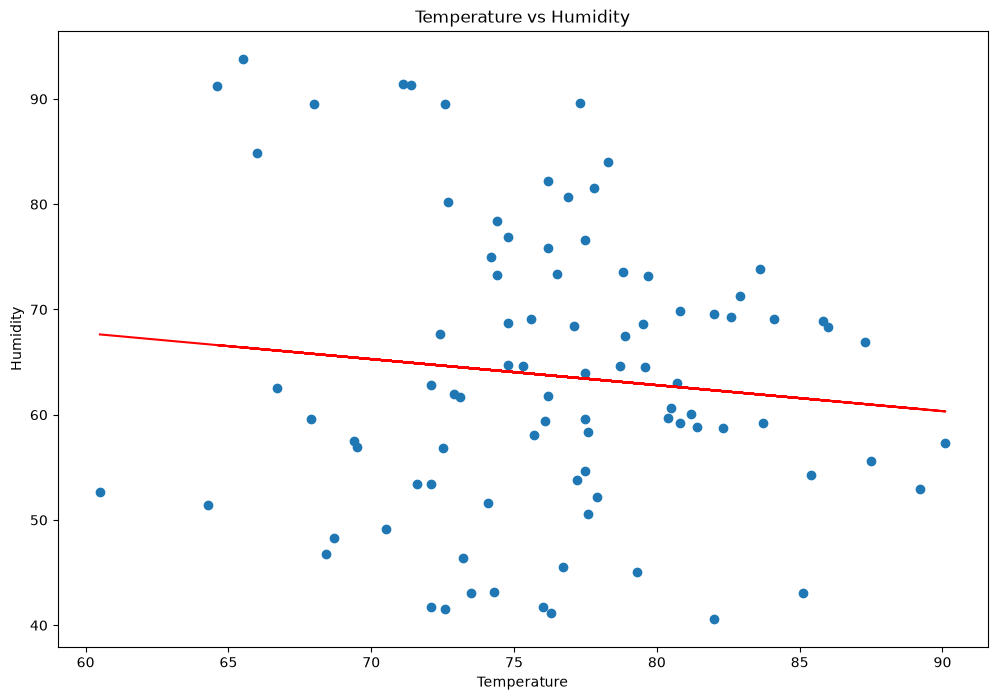

Correlation for Temperature vs Humidity: -0.1065158276140336

There is little to no correlation between Temperature vs Humidity


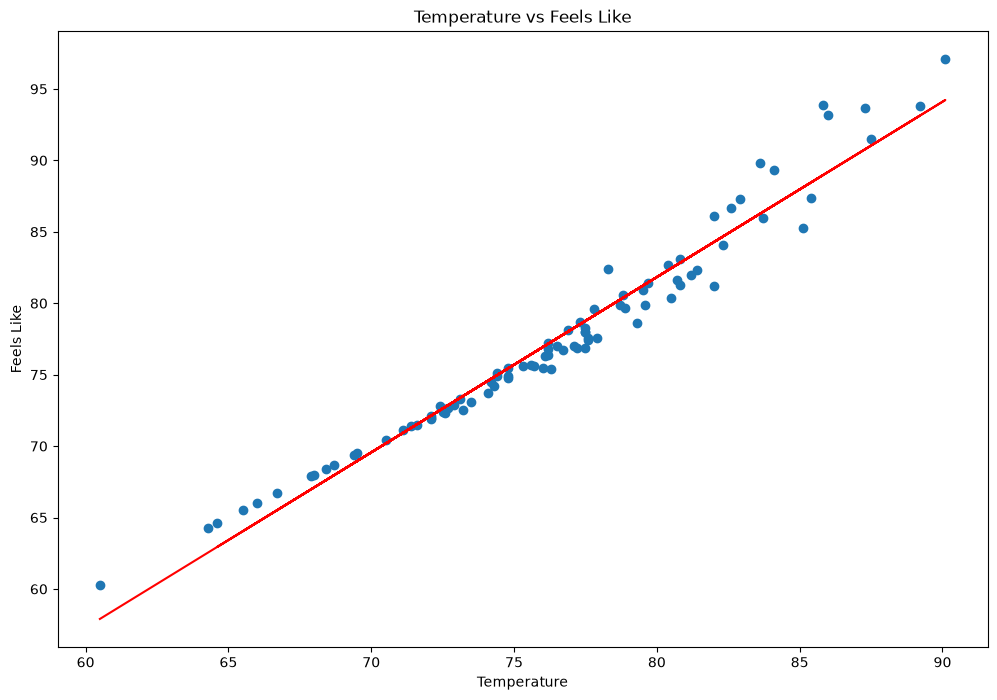

Correlation for Temperature vs Feels Like: 0.9805867839045191

There is a very strong positive correlation between Temperature vs Feels Like


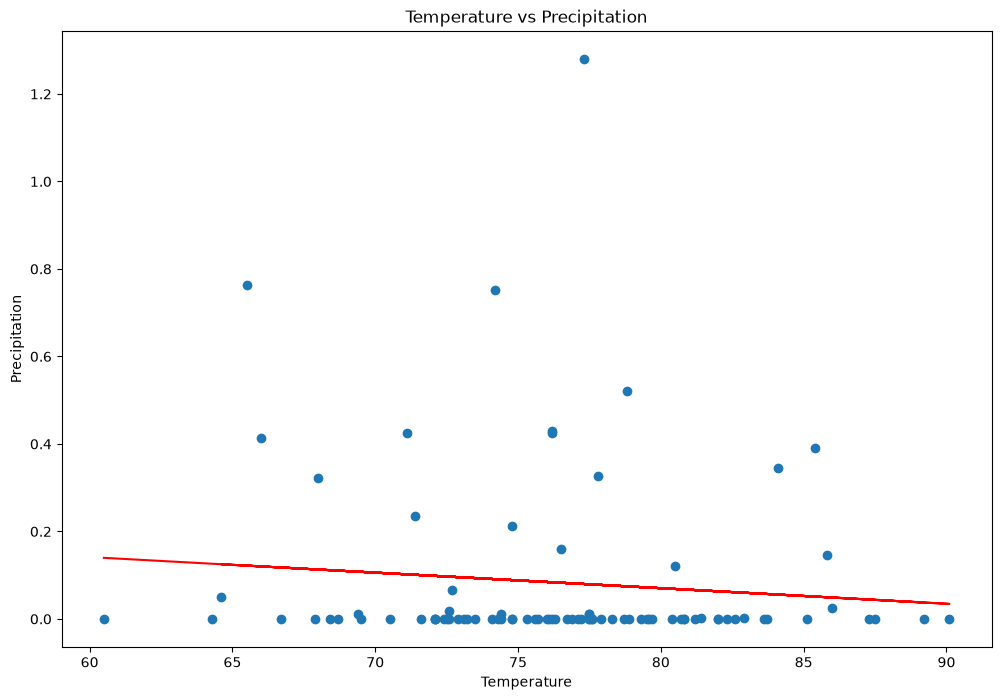

Correlation for Temperature vs Precipitation: -0.10022963417533663

There is little to no correlation between Temperature vs Precipitation


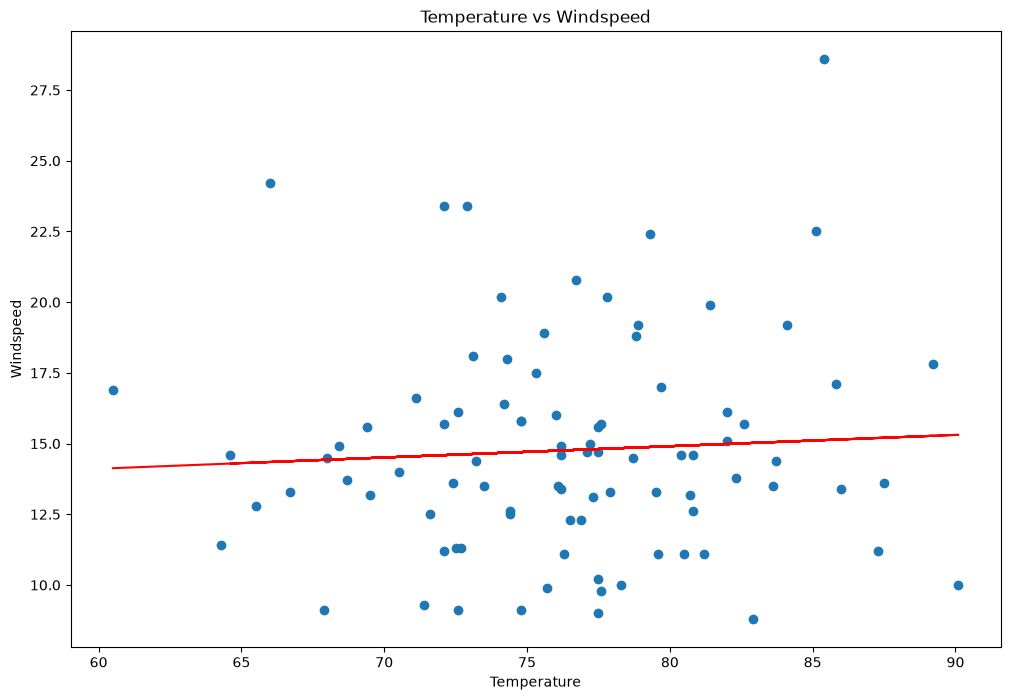

Correlation for Temperature vs Windspeed: 0.06077436089866647

There is little to no correlation between Temperature vs Windspeed


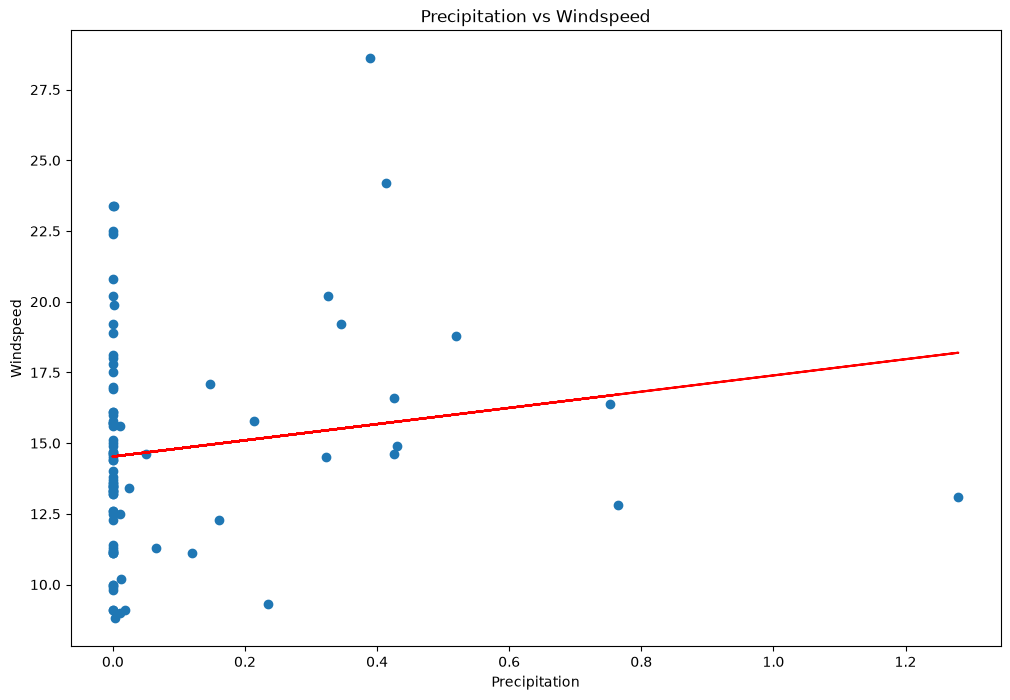

Correlation for Precipitation vs Windspeed: 0.15516189011373205

There is little to no correlation between Precipitation vs Windspeed


In [505]:
#fields = ["Humidity", "Feelslike", "Precip", "Tempmax", "Tempmin", "Windspeed","Temp"]

correlation_of_fields("Temp", "Humidity")
correlation_of_fields("Temp", "Feelslike")
correlation_of_fields("Temp", "Precip")
correlation_of_fields("Temp", "Windspeed")
correlation_of_fields("Precip", "Windspeed")

### Simulation Testing

- Simulation testing using the normal distribution
- Our goal is to simulate 1000 temperatures per day (1000 temps * 7 days a week = 7000) using the normal distribution 
- Simulation based on previous work done in STAT422 Probability models "Poisson Processes" Youtube link: https://youtu.be/uTuHhRkB8Xo

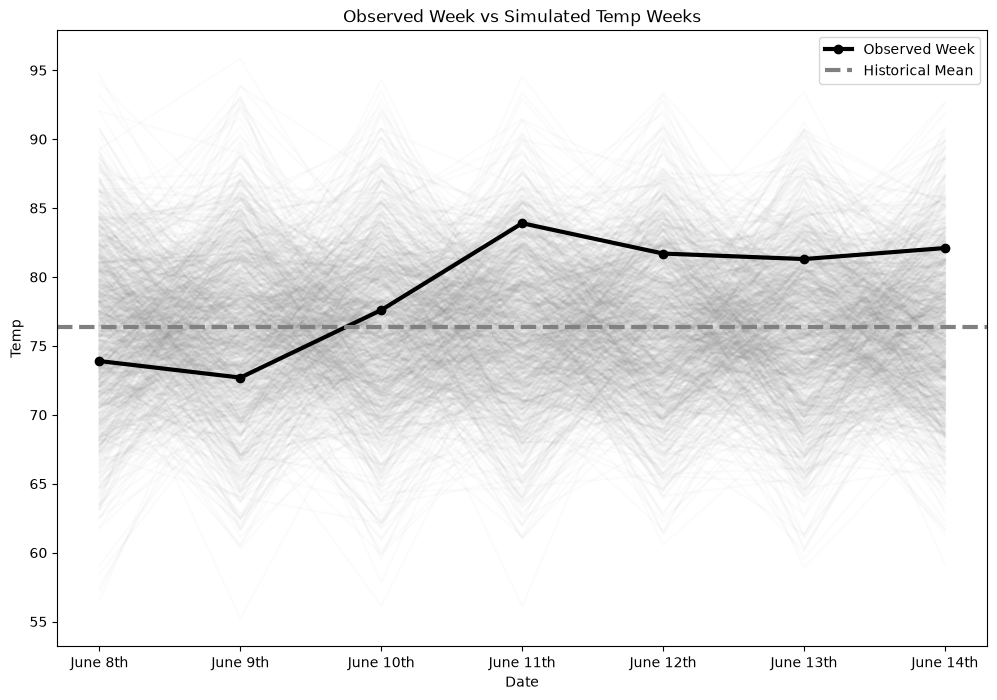

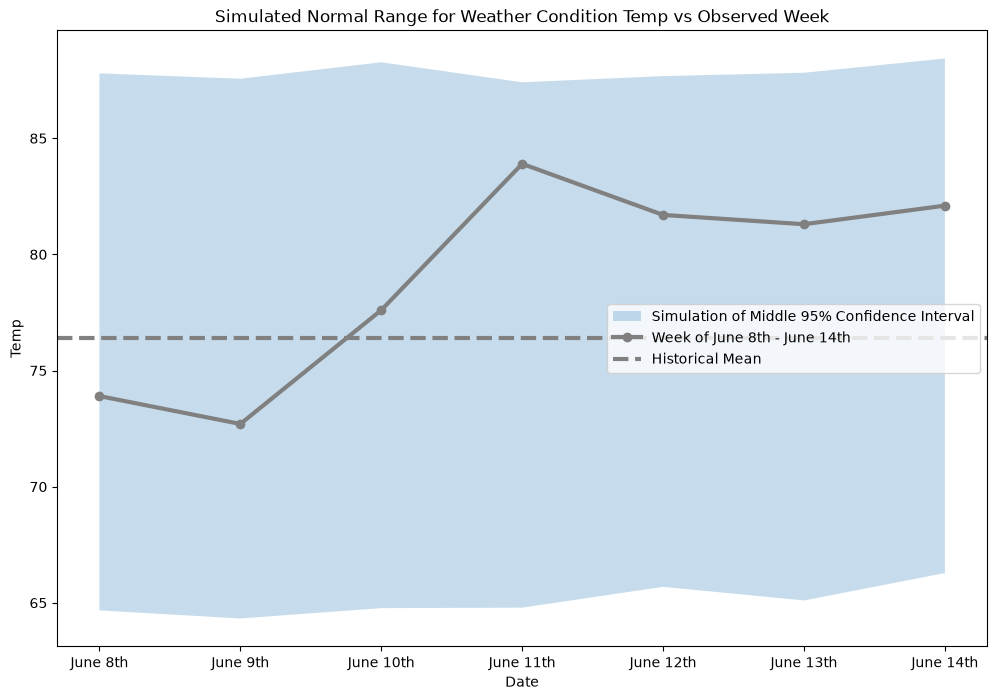

In [506]:
seed = random.randint(1, 422)
sim_days = 1000
np.random.seed(seed)



def display_simulation(label:str, simulations, mean, standard, alpha:float):
    # Simulates 1000 weeks. 7 days per week -> 7,000 labels (i.e, temps, precip, humidity. etc)
    sim = np.random.normal(loc=mu, scale=sigma, size=(sim_days, len(seven_day_forecast[label])))

    dates = [
        "June 8th",
        "June 9th",
        "June 10th",
        "June 11th",
        "June 12th",
        "June 13th",
        "June 14th"
    ]
    plt.figure(figsize=(12, 8))
    for week in sim:
        plt.plot(
            dates,
            week,
            color="grey",
            alpha= .03
        )
    
    plt.plot(dates, seven_day_forecast[label], color="black", linewidth=3, marker="o", label="Observed Week")
    plt.xlabel("Date")
    plt.ylabel(label)
    plt.title(f"Observed Week vs Simulated {label} Weeks")
    plt.axhline(mean, color = 'grey', linestyle="--", linewidth=3, label="Historical Mean")
    plt.legend()
    plt.show()

    # ------------------------------------------- WE CAN TALK ABOUT THIS, BUT I ADDED THIS BELOW  ------------------------------------------------ #
    interval = 100 - alpha
    plt.figure(figsize=(12, 8))
    # Simulating a confidence interval 100% - alpha = ....%.
    # We must split that on both ends so alpha / 2% = ....%
    # (alpha / 2) |CI| (alpha / 2)
    plt.fill_between(dates,
                     np.percentile(sim, alpha / 2, axis=0), # Starting point
                     np.percentile(sim, 100 - (alpha / 2), axis=0), # Ending point
                     alpha=.25, # How shaded in the region is 
                     label=f"Simulation of Middle {interval}% Confidence Interval"
    )

    plt.plot(dates,
             seven_day_forecast[label],
             color='grey',
             linewidth=3,
             marker='o',
             label="Week of June 8th - June 14th"
             
    )
    
    plt.xlabel("Date")
    plt.ylabel(label)
    plt.title(f"Simulated Normal Range for Weather Condition {label} vs Observed Week")
    plt.axhline(mean, color = 'grey', linestyle="--", linewidth=3, label="Historical Mean")
    plt.legend()
    plt.show()
    # ------------------------------------------- ^^^^ WE CAN TALK ABOUT THIS, BUT I ADDED THIS ABOVE ^^^^ ------------------------------------------------ #

temp_mean = combined_df["Temp"].mean()
temp_std = combined_df["Temp"].std()

alpha = 5
# 95 Confidence Interval
display_simulation("Temp", sim_days, temp_mean, temp_std, alpha)

